# PART A:

DOMAIN: Medical

• CONTEXT: Medical research university X is undergoing a deep research on patients with certain conditions. University has an internal AI team. Due to confidentiality the patient’s details and the conditions are masked by the client by providing different datasets to the AI team for developing a AIML model which can predict the condition of the patient depending on the received test results.

• DATA DESCRIPTION: The data consists of biomechanics features of the patients according to their current conditions. Each patient is represented in the data set by six biomechanics attributes derived from the shape and orientation of the condition to their body part.

• PROJECT OBJECTIVE: To Demonstrate the ability to fetch, process and leverage data to generate useful predictions by training Supervised Learning algorithms.

In [1]:
# Importing all libraries needed
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from scipy import stats
%matplotlib inline
sns.set_style('darkgrid')
%matplotlib inline
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn import model_selection
import warnings
warnings.filterwarnings("ignore")
from collections import Counter
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score
from imblearn import under_sampling 
from imblearn import over_sampling
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTENC
from imblearn.over_sampling import SMOTE

In [2]:
# 1. Data Understanding: 
# A. Read all the 3 CSV files as DataFrame and store them into 3 separate variables.
data1 = pd.read_csv('Part1+-+Normal.csv')
data2 = pd.read_csv('Part1+-+Type_H.csv')
data3 = pd.read_csv('Part1+-+Type_S.csv')

In [3]:
# 1. Data Understanding: 
# B. Print Shape and columns of all the 3 DataFrames.
print("First data set shape:", data1.shape)
print("First data set columns:", data1.columns)
print("Second data set shape:", data2.shape)
print("Second data set columns:", data2.columns)
print("Third data set shape:", data3.shape)
print("Third data set columns:", data3.columns)

First data set shape: (100, 7)
First data set columns: Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')
Second data set shape: (60, 7)
Second data set columns: Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')
Third data set shape: (150, 7)
Third data set columns: Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')


In [4]:
# 1. Data Understanding: 
# B. Print Shape and columns of all the 3 DataFrames.
data1.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,38.505273,16.964297,35.112814,21.540976,127.632875,7.986683,Normal
1,54.920858,18.968430,51.601455,35.952428,125.846646,2.001642,Normal
2,44.362490,8.945435,46.902096,35.417055,129.220682,4.994195,Normal
3,48.318931,17.452121,48.000000,30.866809,128.980308,-0.910941,Normal
4,45.701789,10.659859,42.577846,35.041929,130.178314,-3.388910,Normal


In [5]:
# 1. Data Understanding: 
# B. Print Shape and columns of all the 3 DataFrames.
data2.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Type_H
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Type_H
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Type_H
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Type_H
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Type_H


In [6]:
# 1. Data Understanding: 
# B. Print Shape and columns of all the 3 DataFrames.
data3.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,74.377678,32.053104,78.772013,42.324573,143.560690,56.125906,Type_S
1,89.680567,32.704435,83.130732,56.976132,129.955476,92.027277,Type_S
2,44.529051,9.433234,52.000000,35.095817,134.711772,29.106575,Type_S
3,77.690577,21.380645,64.429442,56.309932,114.818751,26.931841,Type_S
4,76.147212,21.936186,82.961502,54.211027,123.932010,10.431972,Type_S


# 1. Data Understanding: 
# C. Compare Column names of all the 3 DataFrames and clearly write observations.
>***First set, P_incidence values between 38 to 50***

>***Second set, P_incidence values between 49 to 70***

>***Third set, P_incidence values between 44 to 90***

>***All the variables has significant effect on target class***

>***class belongs to type_s has higher mean value for alomst all variables***

>***Class belongs to normal has lower values for all variables***

>***Class belongs to Type_H has medium values for all variables***

>***S_Degree is the column which has negative values***

In [9]:
# 1. Data Understanding: 
# D. Print DataTypes of all the 3 DataFrames.
print("First dataset")
print(data1.dtypes)
print("\nSecond dataset")
print(data2.dtypes)
print("\nThird dataset")
print(data3.dtypes)

First dataset
P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class           object
dtype: object

Second dataset
P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class           object
dtype: object

Third dataset
P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class           object
dtype: object


In [10]:
# 1. Data Understanding: 
# E. Observe and share variation in ‘Class’ feature of all the 3 DaraFrames.
print("Variation of class in dataset 1")
print(data1['Class'].value_counts())
print("Variation of class in dataset 2")
print(data2['Class'].value_counts())
print("Variation of class in dataset 3")
print(data3['Class'].value_counts())

Variation of class in dataset 1
Normal    73
Nrmal     27
Name: Class, dtype: int64
Variation of class in dataset 2
Type_H    37
type_h    23
Name: Class, dtype: int64
Variation of class in dataset 3
Type_S    133
tp_s       17
Name: Class, dtype: int64


In [11]:
# Final dataframe
# 2. Data Preparation and Exploration: 
# A. Unify all the variations in ‘Class’ feature for all the 3 DataFrames. 
data1.loc[data1['Class']=='tp_s','Class']='type_s'
data2.loc[data2['Class']=='Nrmal','Class']='normal'
data3.loc[data3['Class']=='type_h','Class']='type_h'
print(data1['Class'].value_counts())
print(data2['Class'].value_counts())
print(data3['Class'].value_counts())

Normal    73
Nrmal     27
Name: Class, dtype: int64
Type_H    37
type_h    23
Name: Class, dtype: int64
Type_S    133
tp_s       17
Name: Class, dtype: int64


In [12]:
# 2. Data Preparation and Exploration: 
# A. Unify all the variations in ‘Class’ feature for all the 3 DataFrames.
# B. Combine all the 3 DataFrames to form a single DataFrame
# Final dataframe
df = data1.append([data2,data3])
df.loc[df['Class']=='tp_s','Class']='Type_S'
df.loc[df['Class']=='Nrmal','Class']='Normal'
df.loc[df['Class']=='type_h','Class']='Type_H'
df['Class'].value_counts()

Type_S    150
Normal    100
Type_H     60
Name: Class, dtype: int64

In [13]:
# 2. Data Preparation and Exploration: 
# C. Print 5 random samples of this DataFrame
df.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,38.505273,16.964297,35.112814,21.540976,127.632875,7.986683,Normal
1,54.920858,18.968430,51.601455,35.952428,125.846646,2.001642,Normal
2,44.362490,8.945435,46.902096,35.417055,129.220682,4.994195,Normal
3,48.318931,17.452121,48.000000,30.866809,128.980308,-0.910941,Normal
4,45.701789,10.659859,42.577846,35.041929,130.178314,-3.388910,Normal


In [14]:
# 2. Data Preparation and Exploration: 
# D. Print Feature-wise percentage of Null values.
df.isnull().mean() * 100

P_incidence    0.0
P_tilt         0.0
L_angle        0.0
S_slope        0.0
P_radius       0.0
S_Degree       0.0
Class          0.0
dtype: float64

In [15]:
# 2. Data Preparation and Exploration: 
# E. Check 5-point summary of the new DataFrame. 
df.describe()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


# P_incidence
>***Mean and median are almost equal***

>***It is normal distribution. Maximum value is little higher than 129***

# P_tilt
>***Mean and median are almost equal***

>***It is normal distribution. Maximum value is little higher than 49***

>***Minimum value range shows, it has negative values as well***

>***75 % of values are less than 22 but maximum value is 49 so there might be little right skewness***

# L_angle
>***Mean and median are almost equal***

>***Distribution might be normal***

>***There might be few outliers because of the maximum value***

# S_slope
>***Mean and Median are nearly equal.***

>***Towards the end there is little devation. 75% of values are lesser than 52 but maximum value is 121.***

# P_radius:

>***Distribution might be normal.***

>***There is no much Deviation.***

# S_Degree:

>***Mean is greater than Median so there might be right skewness in the data .***

>***We can see 75% of values are less than 41 but maximum value is 418 so there is obvious outliers in the data.***


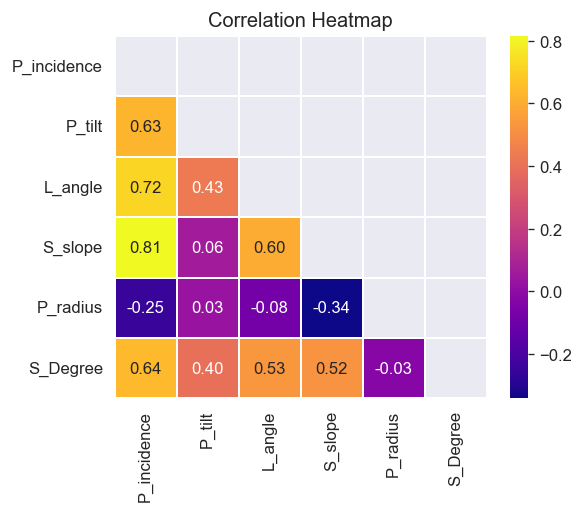

In [16]:
# 3. Data Analysis:
# A. Visualize a heatmap to understand correlation between all features
plt.figure(dpi = 120,figsize= (5,4))
mask = np.triu(np.ones_like(df.corr()))
sns.heatmap(df.corr(),mask = mask, fmt = ".2f",annot=True,lw=1,cmap = 'plasma')
plt.yticks(rotation = 0)
plt.xticks(rotation = 90)
plt.title('Correlation Heatmap')
plt.show()

# 3. Data Analysis:
# B. Share insights on correlation. [2 Marks]
> A. Features having stronger correlation with correlation value.

>> ***Correlation between s_degree and p_incidence have stronger(high) correlation.***

> B. Features having weaker correlation with correlation value.

>> ***S_degree and p_radius has weaker(negative) correlation***

first data


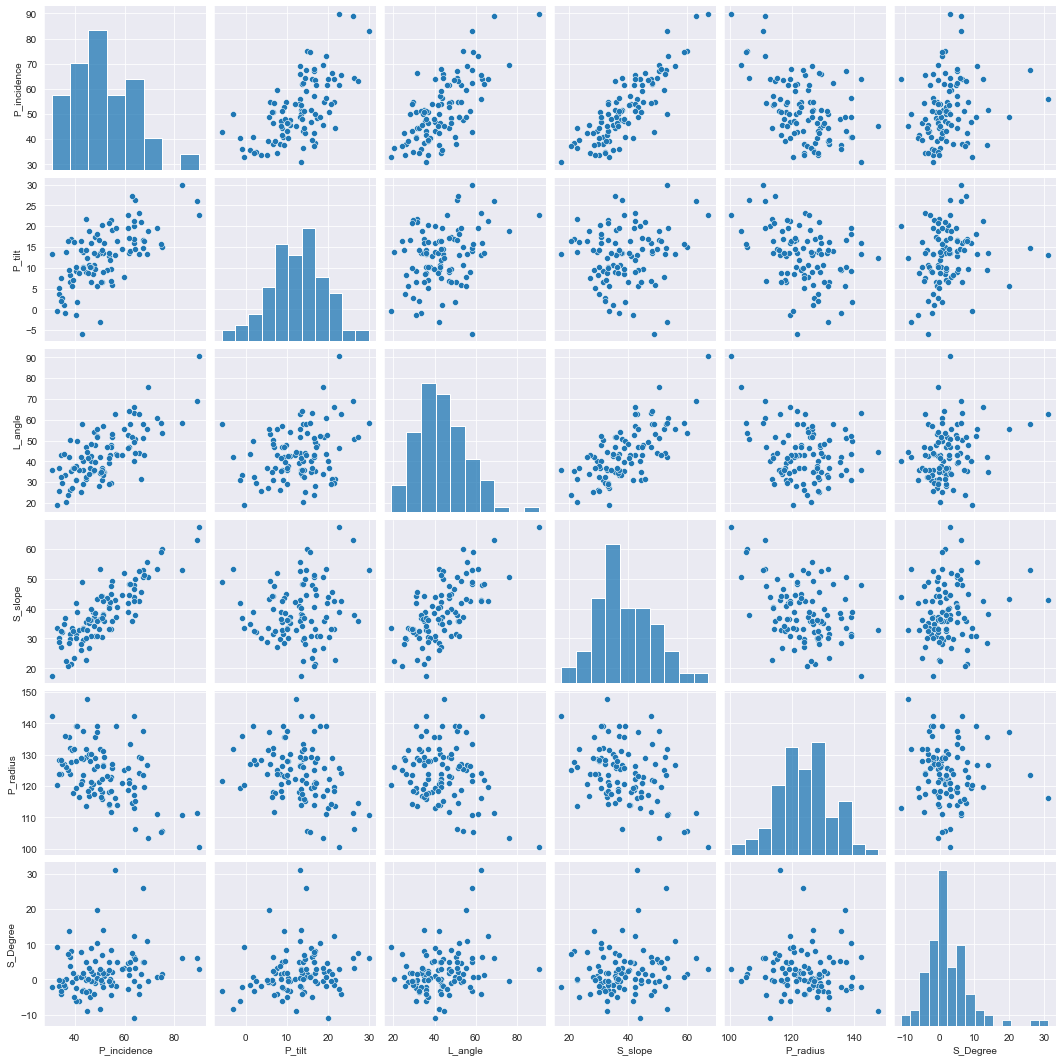

In [17]:
# 3. Data Analysis:
# C. Visualize a pairplot with 3 classes distinguished by colors and share insights
print("first data")
sns.pairplot(data1);

second data


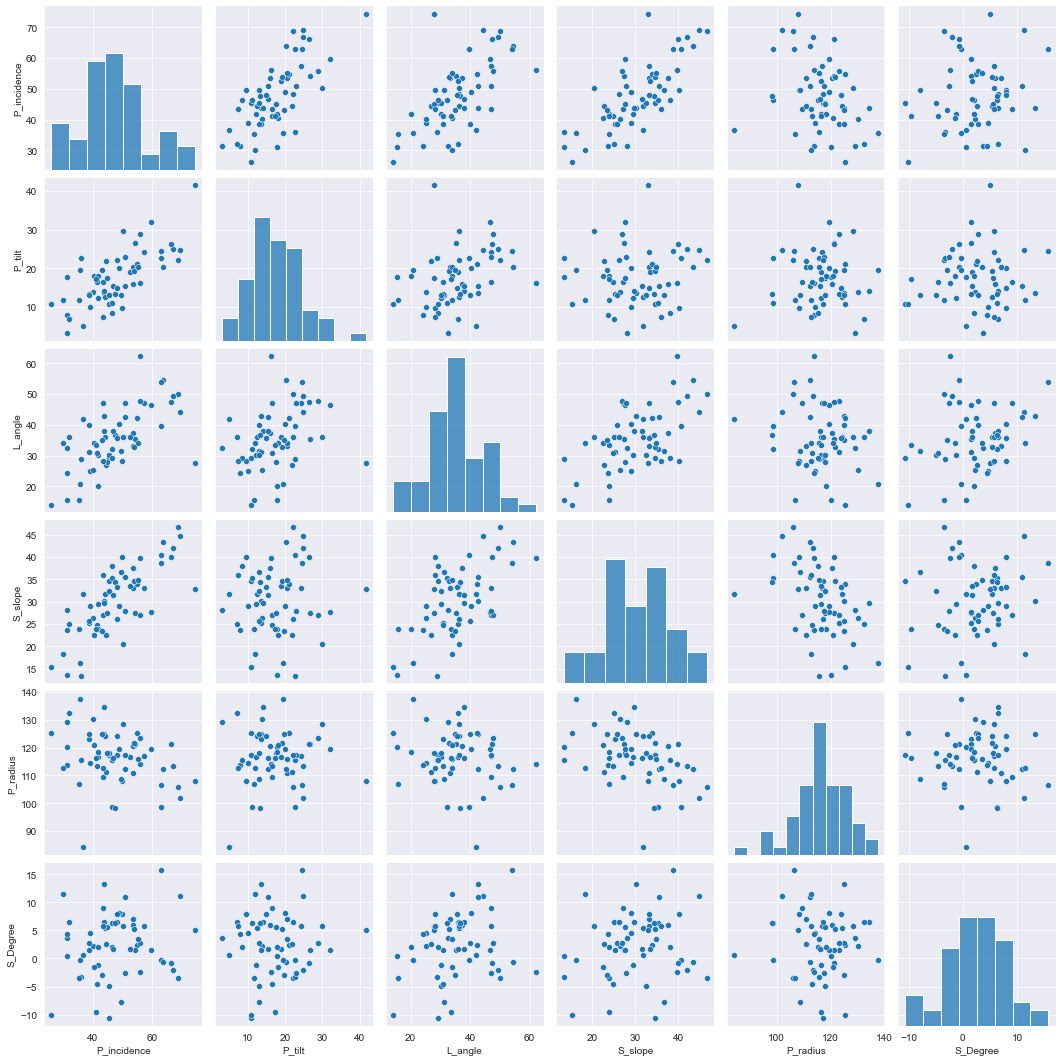

In [18]:
# 3. Data Analysis:
# C. Visualize a pairplot with 3 classes distinguished by colors and share insights
print("second data")
sns.pairplot(data2);

third data


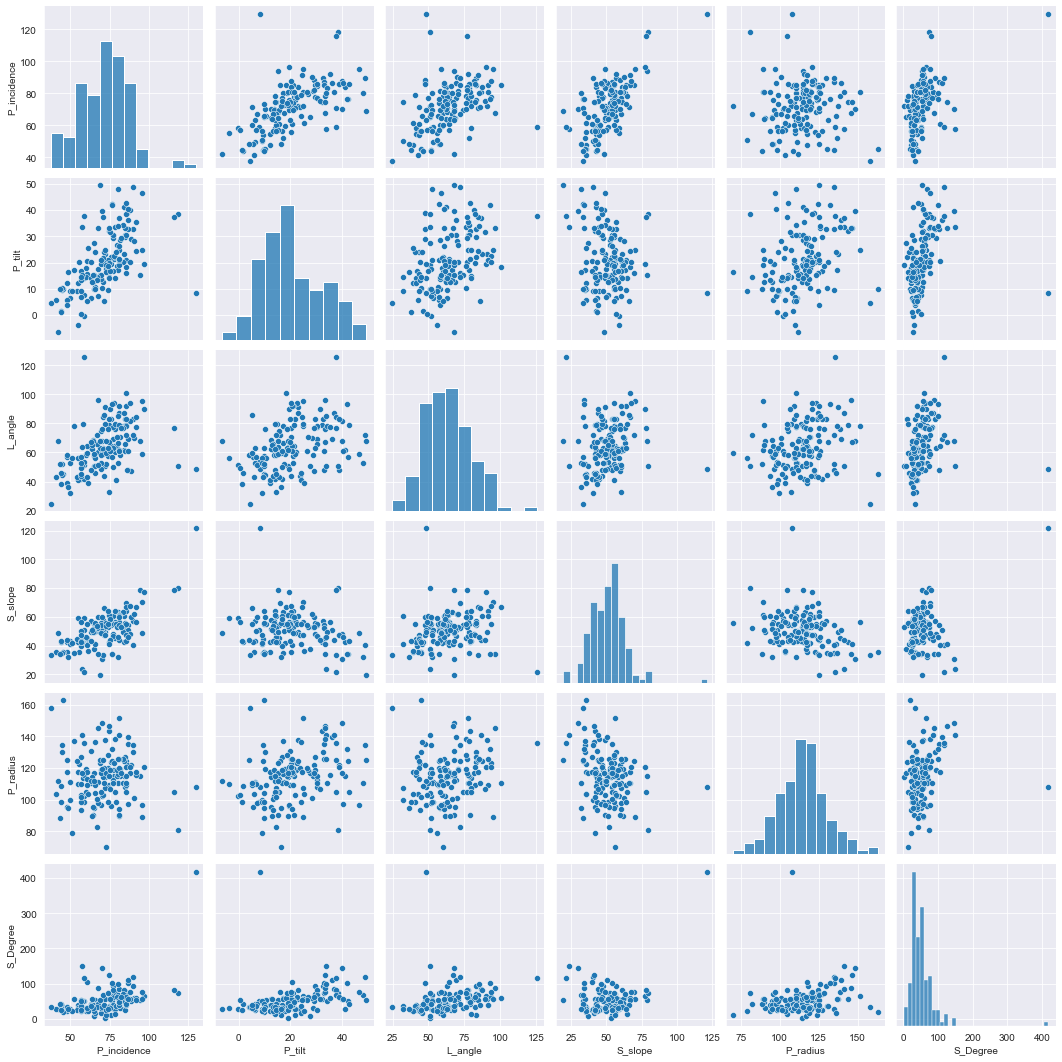

In [15]:
# 3. Data Analysis:
# C. Visualize a pairplot with 3 classes distinguished by colors and share insights
print("third data")
sns.pairplot(data3);

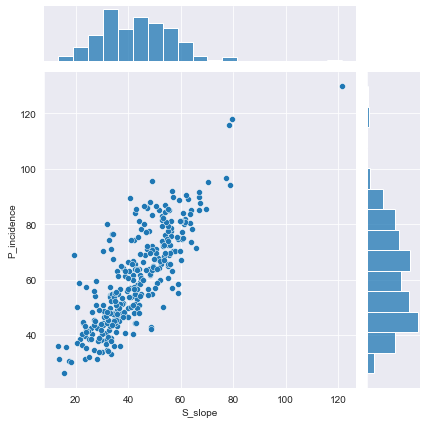

In [23]:
# 3. Data Analysis:
# D. Visualize a jointplot for ‘P_incidence’ and ‘S_slope’ and share insights
indexed_df = df.reset_index()
sns.jointplot(data=indexed_df, x="S_slope", y="P_incidence");

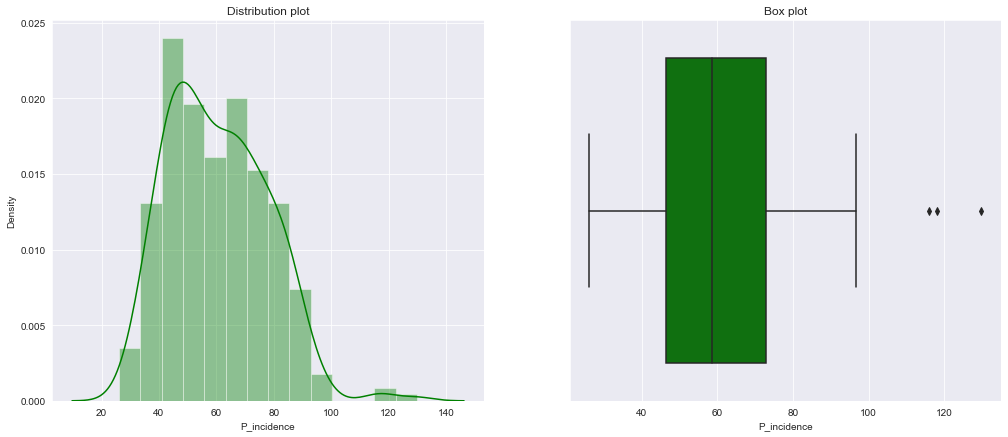

 Total Number of outliers in P_incidence: 3


In [24]:
# 3. Data Analysis:
# E. Visualize a boxplot to check distribution of the features and share insights
# P_incidence
f, axes = plt.subplots(1, 2, figsize=(17,7))
sns.boxplot(x = 'P_incidence', data=df,  orient='h' , ax=axes[1],color='Green')
sns.distplot(df['P_incidence'],  ax=axes[0],color='Green')
axes[0].set_title('Distribution plot')
axes[1].set_title('Box plot')
plt.show()
#checking count of outliers.
q25,q75=np.percentile(df['P_incidence'],25),np.percentile(df['P_incidence'],75)
IQR=q75-q25
Threshold=IQR*1.5
lower,upper=q25-Threshold,q75+Threshold
Outliers=[i for i in df['P_incidence'] if i < lower or i > upper]
print('{} Total Number of outliers in P_incidence: {}'.format('\033[1m',len(Outliers)))

>***Normality is maintained with very less extreme values***

>***We can see three outliers exists in the column***

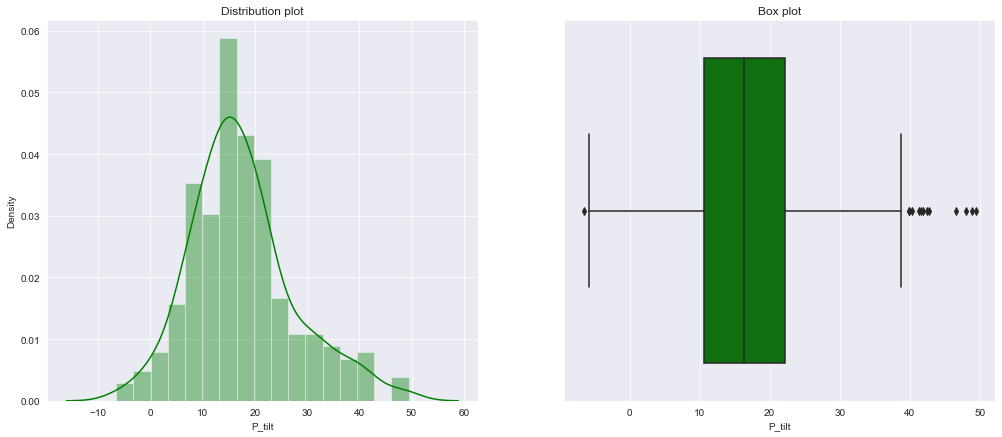

 Total Number of outliers in P_tilt: 13


In [25]:
# 3. Data Analysis:
# E. Visualize a boxplot to check distribution of the features and share insights
# P_tilt
f, axes = plt.subplots(1, 2, figsize=(17,7))
sns.boxplot(x = 'P_tilt', data=df,  orient='h' , ax=axes[1],color='Green')
sns.distplot(df['P_tilt'],  ax=axes[0],color='Green')
axes[0].set_title('Distribution plot')
axes[1].set_title('Box plot')
plt.show()
#checking count of outliers.
q25,q75=np.percentile(df['P_tilt'],25),np.percentile(df['P_tilt'],75)
IQR=q75-q25
Threshold=IQR*1.5
lower,upper=q25-Threshold,q75+Threshold
Outliers=[i for i in df['P_tilt'] if i < lower or i > upper]
print('{} Total Number of outliers in P_tilt: {}'.format('\033[1m',len(Outliers)))

> **Data is Normally distributed and we can see one peakness in the center**

> **It is has little skewness towards right side**

> **We can see one outlier in negative end and few outliers in positive end.**

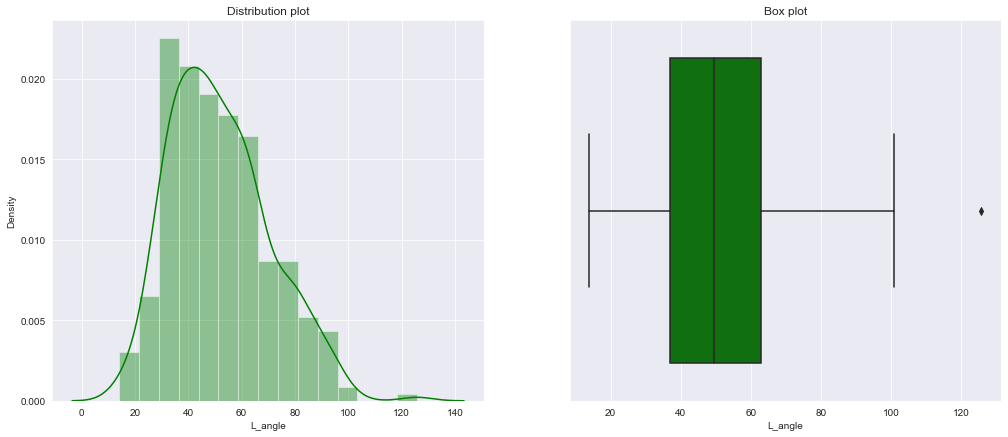

 Total Number of outliers in L_angle: 1


In [26]:
# 3. Data Analysis:
# E. Visualize a boxplot to check distribution of the features and share insights
# L_angle
f, axes = plt.subplots(1, 2, figsize=(17,7))
sns.boxplot(x = 'L_angle', data=df,  orient='h' , ax=axes[1],color='Green')
sns.distplot(df['L_angle'],  ax=axes[0],color='Green')
axes[0].set_title('Distribution plot')
axes[1].set_title('Box plot')
plt.show()
#checking count of outliers.
q25,q75=np.percentile(df['L_angle'],25),np.percentile(df['L_angle'],75)
IQR=q75-q25
Threshold=IQR*1.5
lower,upper=q25-Threshold,q75+Threshold
Outliers=[i for i in df['L_angle'] if i < lower or i > upper]
print('{} Total Number of outliers in L_angle: {}'.format('\033[1m',len(Outliers)))

> **It is Normally distributed**

> **Little right skewness because of one outlier**

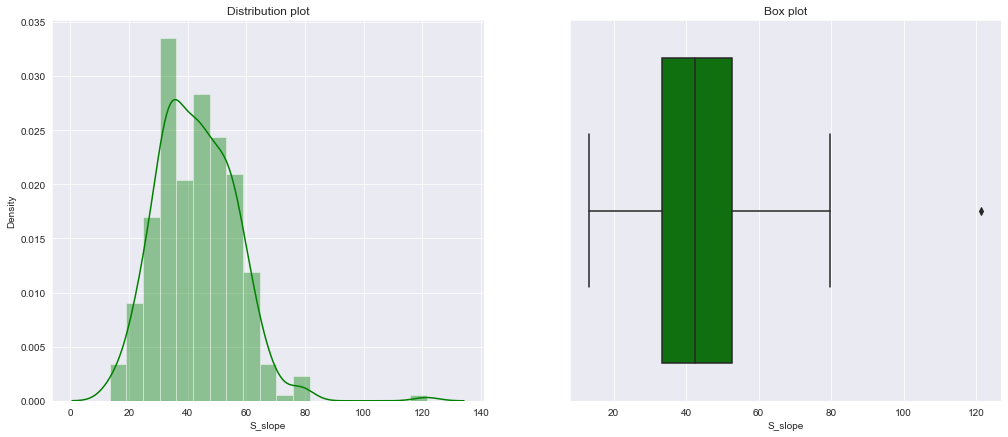

 Total Number of outliers in S_slope: 1


In [27]:
# 3. Data Analysis:
# E. Visualize a boxplot to check distribution of the features and share insights
# S_slope
f, axes = plt.subplots(1, 2, figsize=(17,7))
sns.boxplot(x = 'S_slope', data=df,  orient='h' , ax=axes[1],color='Green')
sns.distplot(df['S_slope'],  ax=axes[0],color='Green')
axes[0].set_title('Distribution plot')
axes[1].set_title('Box plot')
plt.show()
#checking count of outliers.
q25,q75=np.percentile(df['S_slope'],25),np.percentile(df['S_slope'],75)
IQR=q75-q25
Threshold=IQR*1.5
lower,upper=q25-Threshold,q75+Threshold
Outliers=[i for i in df['S_slope'] if i < lower or i > upper]
print('{} Total Number of outliers in S_slope: {}'.format('\033[1m',len(Outliers)))

> **There is right skewness due to one outlier**

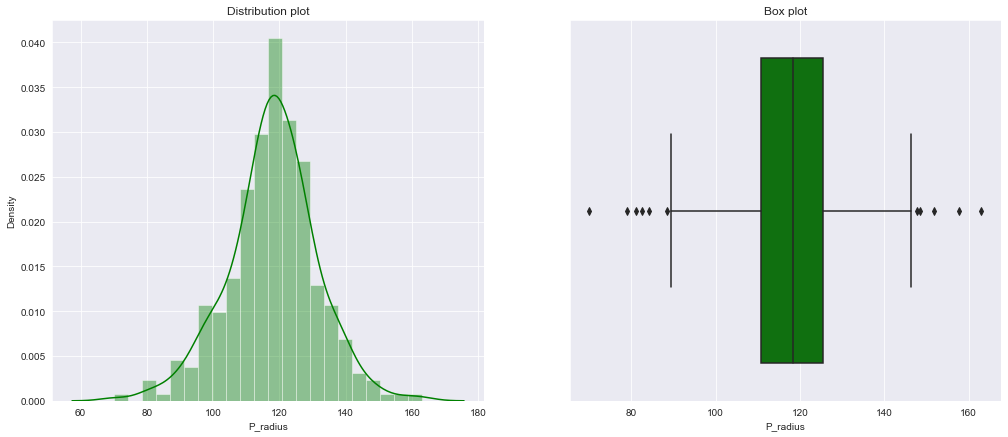

 Total Number of outliers in P_radius: 11


In [28]:
# 3. Data Analysis:
# E. Visualize a boxplot to check distribution of the features and share insights
# P_radius
f, axes = plt.subplots(1, 2, figsize=(17,7))
sns.boxplot(x = 'P_radius', data=df,  orient='h' , ax=axes[1],color='Green')
sns.distplot(df['P_radius'],  ax=axes[0],color='Green')
axes[0].set_title('Distribution plot')
axes[1].set_title('Box plot')
plt.show()
#checking count of outliers.
q25,q75=np.percentile(df['P_radius'],25),np.percentile(df['P_radius'],75)
IQR=q75-q25
Threshold=IQR*1.5
lower,upper=q25-Threshold,q75+Threshold
Outliers=[i for i in df['P_radius'] if i < lower or i > upper]
print('{} Total Number of outliers in P_radius: {}'.format('\033[1m',len(Outliers)))

> **Data is normally distributed**

> **We can see outliers at both the ends.**

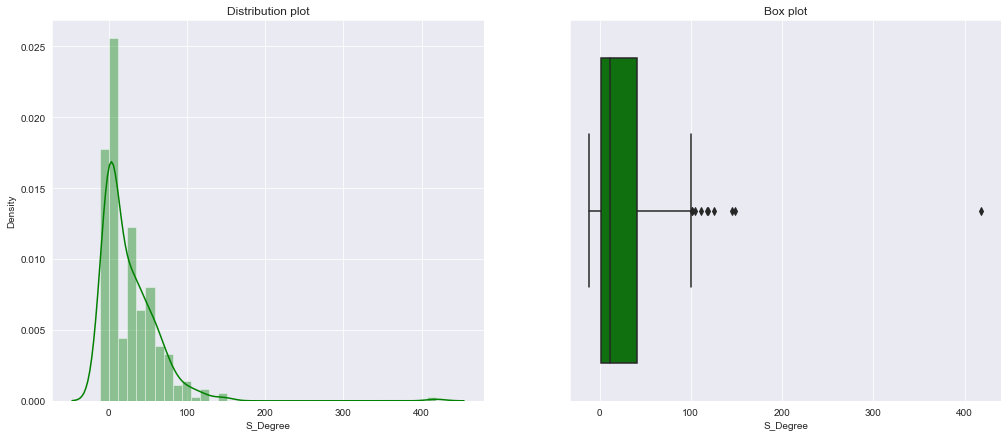

 Total Number of outliers in S_Degree: 10


In [29]:
# 3. Data Analysis:
# E. Visualize a boxplot to check distribution of the features and share insights
# S_degree
f, axes = plt.subplots(1, 2, figsize=(17,7))
sns.boxplot(x = 'S_Degree', data=df,  orient='h' , ax=axes[1],color='Green')
sns.distplot(df['S_Degree'],  ax=axes[0],color='Green')
axes[0].set_title('Distribution plot')
axes[1].set_title('Box plot')
plt.show()
#checking count of outliers.
q25,q75=np.percentile(df['S_Degree'],25),np.percentile(df['S_Degree'],75)
IQR=q75-q25
Threshold=IQR*1.5
lower,upper=q25-Threshold,q75+Threshold
Outliers=[i for i in df['S_Degree'] if i < lower or i > upper]
print('{} Total Number of outliers in S_Degree: {}'.format('\033[1m',len(Outliers)))

> **There is Positive Skewness in the data**

> **Hugely affected by Outliers**

In [30]:
# 4. Model Building: 
# A. Split data into X and Y
X=df.drop(columns='Class')
y=df['Class'] #target

In [31]:
# 4. Model Building: 
# B. Split data into train and test with 80:20 proportion. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=10)

In [32]:
# 4. Model Building: 
# C. Train a Supervised Learning Classification base model using KNN classifier. 
KNN = KNeighborsClassifier(n_neighbors= 5 , metric = 'euclidean' )
KNN.fit(X_train, y_train)
predicted_labels = KNN.predict(X_test)
print('Accuracy on Training data:',KNN.score(X_train, y_train) )
print('Accuracy on Test data:',KNN.score(X_test, y_test) )

Accuracy on Training data: 0.9153225806451613
Accuracy on Test data: 0.7096774193548387


Train score


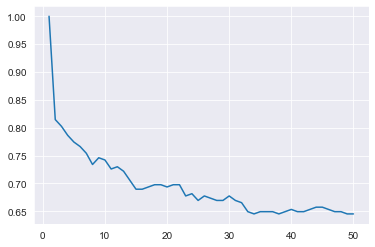

Test score


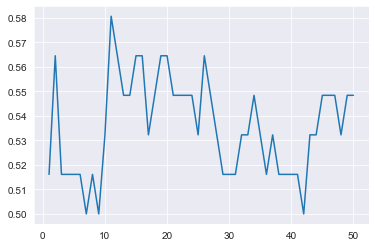

In [30]:
# 4. Model Building: 
# D. Print all the possible performance metrics for both train and test data. 
train_score=[]
test_score=[]
for k in range(1,51):
    KNN = KNeighborsClassifier(n_neighbors= k , metric = 'euclidean' ) 
    KNN.fit(X_train, y_train)
    train_score.append(KNN.score(X_train, y_train))
    test_score.append(KNN.score(X_test, y_test))
print('Train score')
plt.plot(range(1,51),train_score)
plt.show()
print('Test score')
plt.plot(range(1,51),test_score)
plt.show()

In [33]:
# 5. Performance Improvement:
# A. Experiment with various parameters to improve performance of the base model. 
X_Scaled=X.apply(zscore)
LR_model=LogisticRegression()
KNN_model=KNeighborsClassifier(n_neighbors=13)
GN_model=GaussianNB()
svc_model_linear = SVC(kernel='linear',C=1,gamma=.6)
svc_model_rbf = SVC(kernel='rbf',degree=2,C=.009)
svc_model_poly  = SVC(kernel='poly',degree=2,gamma=0.1,C=.01)

LR: 0.864516 (0.049556)
KNN: 0.829032 (0.054074)
NB: 0.825806 (0.035921)
SVM-linear: 0.848387 (0.066188)
SVM-poly: 0.819355 (0.050389)
SVM-rbf: 0.483871 (0.070674)


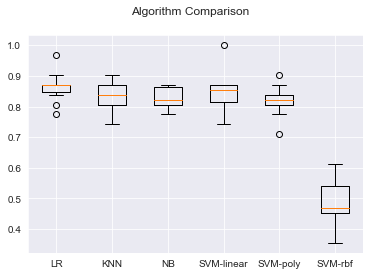

In [30]:
# 5. Performance Improvement:
# A. Experiment with various parameters to improve performance of the base model. 
seed = 7
# prepare models
models = []
models.append(('LR', LR_model))
models.append(('KNN', KNN_model))
models.append(('NB', GN_model))
models.append(('SVM-linear', svc_model_linear))
models.append(('SVM-poly', svc_model_poly))
models.append(('SVM-rbf', svc_model_rbf))
# evaluate each model in turn
results = []
names = []
scoring = 'accuracy'
for name, model in models:
	kfold = model_selection.KFold(n_splits=10, random_state=seed,shuffle=True)
	cv_results = model_selection.cross_val_score(model,  X,y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
	print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

LR: 0.848387 (0.061290)
KNN: 0.780645 (0.053591)
NB: 0.825806 (0.035921)
SVM-linear: 0.851613 (0.070968)
SVM-poly: 0.483871 (0.070674)
SVM-rbf: 0.483871 (0.070674)


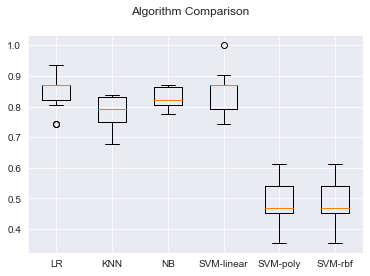

In [34]:
# 5. Performance Improvement:
# B. Clearly showcase improvement in performance achieved. 
seed = 7
# prepare models
models = []
models.append(('LR', LR_model))
models.append(('KNN', KNN_model))
models.append(('NB', GN_model))
models.append(('SVM-linear', svc_model_linear))
models.append(('SVM-poly', svc_model_poly))
models.append(('SVM-rbf', svc_model_rbf))
# evaluate each model in turn
results = []
names = []
scoring = 'accuracy'
for name, model in models:
	kfold = model_selection.KFold(n_splits=10, random_state=seed,shuffle=True)
	cv_results = model_selection.cross_val_score(model,X_Scaled,y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
	print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

# 5. Performance Improvement:
# C. Clearly state which parameters contributed most to improve model performance.
> ***When the scaled values are used instead of normal values Logistic regression is performing well.***

> ***Logistic Regression gives 81% accuracy with little standard deviation.***

# PART B
DOMAIN: Banking, Marketing
• CONTEXT: A bank X is on a massive digital transformation for all its departments. Bank has a growing customer base whee majority of them are
liability customers (depositors) vs borrowers (asset customers). The bank is interested in expanding the borrowers base rapidly to bring in more business via loan interests. A campaign that the bank ran in last quarter showed an average single digit conversion rate. Digital transformation being the core strength of the business strategy, marketing department wants to devise effective campaigns with better target marketing to increase the conversion ratio to double digit with same budget as per last campaign.

• DATA DICTIONARY:
1. Team: Team’s name
2. ID: Customer ID
3. Age: Customer’s approximate age.
4. CustomerSince: Customer of the bank since. [unit is masked]
5. HighestSpend: Customer’s highest spend so far in one transaction. [unit is masked]
6. ZipCode: Customer’s zip code.
7. HiddenScore: A score associated to the customer which is masked by the bank as an IP.
8. MonthlyAverageSpend: Customer’s monthly average spend so far. [unit is masked]
9. Level: A level associated to the customer which is masked by the bank as an IP.
10. Mortgage: Customer’s mortgage. [unit is masked]
11. Security: Customer’s security asset with the bank. [unit is masked]
12. FixedDepositAccount: Customer’s fixed deposit account with the bank. [unit is masked]
13. InternetBanking: if the customer uses internet banking.
14. CreditCard: if the customer uses bank’s credit card.
15. LoanOnCard: if the customer has a loan on credit card.

• PROJECT OBJECTIVE: Build a Machine Learning model to perform focused marketing by predicting the potential customers who will convert using the historical dataset.

In [2]:
# PART B
# 1. Data Understanding and Preparation:
# A. Read both the Datasets ‘Data1’ and ‘Data 2’ as DataFrame and store them into two separate variables. 
df1=pd.read_csv('Part2+-+Data1.csv')
df2=pd.read_csv('Part2+-Data2.csv')
print(df1.isnull().sum())
print(df2.isnull().sum())
df2['LoanOnCard'] = df2['LoanOnCard'].fillna(0)
print(df2.isnull().sum())

ID                     0
Age                    0
CustomerSince          0
HighestSpend           0
ZipCode                0
HiddenScore            0
MonthlyAverageSpend    0
Level                  0
dtype: int64
ID                      0
Mortgage                0
Security                0
FixedDepositAccount     0
InternetBanking         0
CreditCard              0
LoanOnCard             20
dtype: int64
ID                     0
Mortgage               0
Security               0
FixedDepositAccount    0
InternetBanking        0
CreditCard             0
LoanOnCard             0
dtype: int64


In [3]:
# PART B
# 1. Data Understanding and Preparation:
# B. Print shape and Column Names and DataTypes of both the Dataframes.
print("shape of data1")
print(df1.shape)
print("\ndatatypes")
print(df1.dtypes)
df1.head()

shape of data1
(5000, 8)

datatypes
ID                       int64
Age                      int64
CustomerSince            int64
HighestSpend             int64
ZipCode                  int64
HiddenScore              int64
MonthlyAverageSpend    float64
Level                    int64
dtype: object


,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level
0,1,25,1,49,91107,4,1.6,1
1,2,45,19,34,90089,3,1.5,1
2,3,39,15,11,94720,1,1.0,1
3,4,35,9,100,94112,1,2.7,2
4,5,35,8,45,91330,4,1.0,2


In [4]:
# PART B
# 1. Data Understanding and Preparation:
# B. Print shape and Column Names and DataTypes of both the Dataframes.
print("shape of data2")
print(df2.shape)
print("\ndatatypes")
print(df2.dtypes)
df2.head()

shape of data2
(5000, 7)

datatypes
ID                       int64
Mortgage                 int64
Security                 int64
FixedDepositAccount      int64
InternetBanking          int64
CreditCard               int64
LoanOnCard             float64
dtype: object


,ID,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,1,0,1,0,0,0,0.0
1,2,0,1,0,0,0,0.0
2,3,0,0,0,0,0,0.0
3,4,0,0,0,0,0,0.0
4,5,0,0,0,0,1,0.0


In [5]:
# PART B
# 1. Data Understanding and Preparation:
# C. Merge both the Dataframes on ‘ID’ feature to form a single DataFrame
df_merged=df1.merge(df2,left_on='ID',right_on='ID') 

In [6]:
# PART B
# 1. Data Understanding and Preparation:
# C. Merge both the Dataframes on ‘ID’ feature to form a single DataFrame
print(df_merged.head())
df_merged.dtypes

   ID  Age  CustomerSince  HighestSpend  ZipCode  HiddenScore  \
0   1   25              1            49    91107            4   
1   2   45             19            34    90089            3   
2   3   39             15            11    94720            1   
3   4   35              9           100    94112            1   
4   5   35              8            45    91330            4   

   MonthlyAverageSpend  Level  Mortgage  Security  FixedDepositAccount  \
0                  1.6      1         0         1                    0   
1                  1.5      1         0         1                    0   
2                  1.0      1         0         0                    0   
3                  2.7      2         0         0                    0   
4                  1.0      2         0         0                    0   

   InternetBanking  CreditCard  LoanOnCard  
0                0           0         0.0  
1                0           0         0.0  
2                0           

ID                       int64
Age                      int64
CustomerSince            int64
HighestSpend             int64
ZipCode                  int64
HiddenScore              int64
MonthlyAverageSpend    float64
Level                    int64
Mortgage                 int64
Security                 int64
FixedDepositAccount      int64
InternetBanking          int64
CreditCard               int64
LoanOnCard             float64
dtype: object

In [7]:
# PART B
# 1. Data Understanding and Preparation:
# D. Change Datatype of below features to ‘Object’ [1 Marks]
#‘CreditCard’, ‘InternetBanking’, ‘FixedDepositAccount’, ‘Security’, ‘Level’, ‘HiddenScore’.
col=['HiddenScore','Level','Security','FixedDepositAccount', 'InternetBanking', 'CreditCard', 'LoanOnCard']
for i in col:
    df_merged[i]=df_merged[i].astype('object')
df_merged.dtypes

ID                       int64
Age                      int64
CustomerSince            int64
HighestSpend             int64
ZipCode                  int64
HiddenScore             object
MonthlyAverageSpend    float64
Level                   object
Mortgage                 int64
Security                object
FixedDepositAccount     object
InternetBanking         object
CreditCard              object
LoanOnCard              object
dtype: object

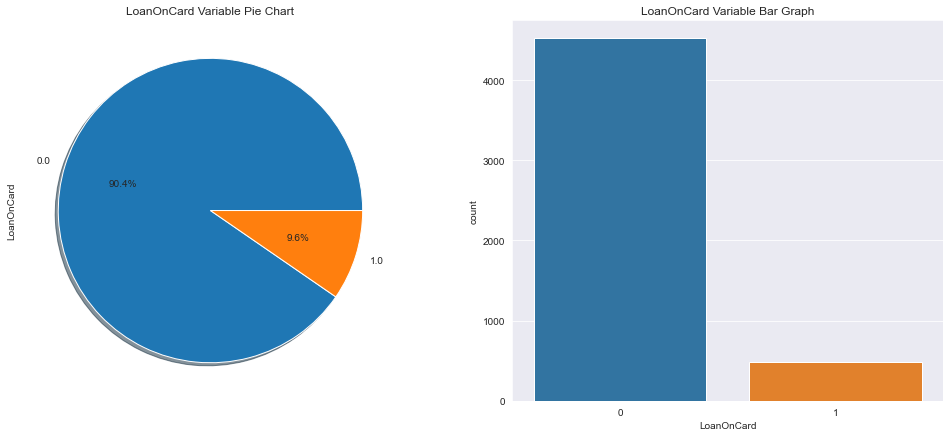

In [26]:
# PART B
# 2. Data Exploration and Analysis:
# A. Visualize distribution of Target variable ‘LoanOnCard’ and clearly share insights
f,axes=plt.subplots(1,2,figsize=(17,7))
df_merged['LoanOnCard'].value_counts().plot.pie(autopct='%1.1f%%',ax=axes[0],shadow=True)
sns.countplot('LoanOnCard',data=df_merged,ax=axes[1],order=[0,1])
axes[0].set_title('LoanOnCard Variable Pie Chart')
axes[1].set_title('LoanOnCard Variable Bar Graph')
plt.show();

In [41]:
# PART B
# 2. Data Exploration and Analysis:
# B. Check the percentage of missing values and impute if required.
# yet to complete
print(df_merged.isnull().sum())
print("\n\n")
print(df_merged.info())
print(df_merged.head())

ID                     0
Age                    0
CustomerSince          0
HighestSpend           0
ZipCode                0
HiddenScore            0
MonthlyAverageSpend    0
Level                  0
Mortgage               0
Security               0
FixedDepositAccount    0
InternetBanking        0
CreditCard             0
LoanOnCard             0
dtype: int64



<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   5000 non-null   int64  
 1   Age                  5000 non-null   int64  
 2   CustomerSince        5000 non-null   int64  
 3   HighestSpend         5000 non-null   int64  
 4   ZipCode              5000 non-null   int64  
 5   HiddenScore          5000 non-null   object 
 6   MonthlyAverageSpend  5000 non-null   float64
 7   Level                5000 non-null   object 
 8   Mortgage             5

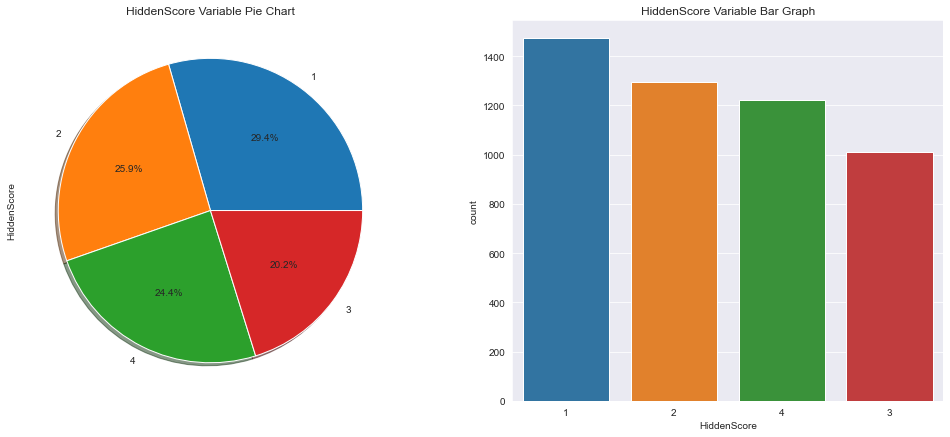

In [42]:
# PART B
# 2. Data Exploration and Analysis:
# C. Check for unexpected values in each categorical variable and impute with best suitable value.
# HiddenScore
f,axes=plt.subplots(1,2,figsize=(17,7))
df_merged['HiddenScore'].value_counts().plot.pie(autopct='%1.1f%%',ax=axes[0],shadow=True)
sns.countplot('HiddenScore',data=df_merged,ax=axes[1],order=[1,2,4,3])
axes[0].set_title('HiddenScore Variable Pie Chart')
axes[1].set_title('HiddenScore Variable Bar Graph')
plt.show()

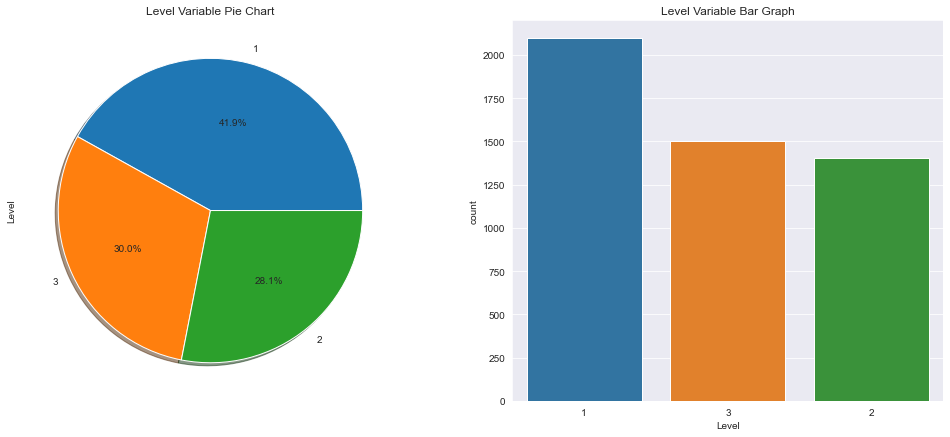

In [43]:
# PART B
# 2. Data Exploration and Analysis:
# C. Check for unexpected values in each categorical variable and impute with best suitable value.
# Level
f,axes=plt.subplots(1,2,figsize=(17,7))
df_merged['Level'].value_counts().plot.pie(autopct='%1.1f%%',ax=axes[0],shadow=True)
sns.countplot('Level',data=df_merged,ax=axes[1],order=[1,3,2])
axes[0].set_title('Level Variable Pie Chart')
axes[1].set_title('Level Variable Bar Graph')
plt.show()

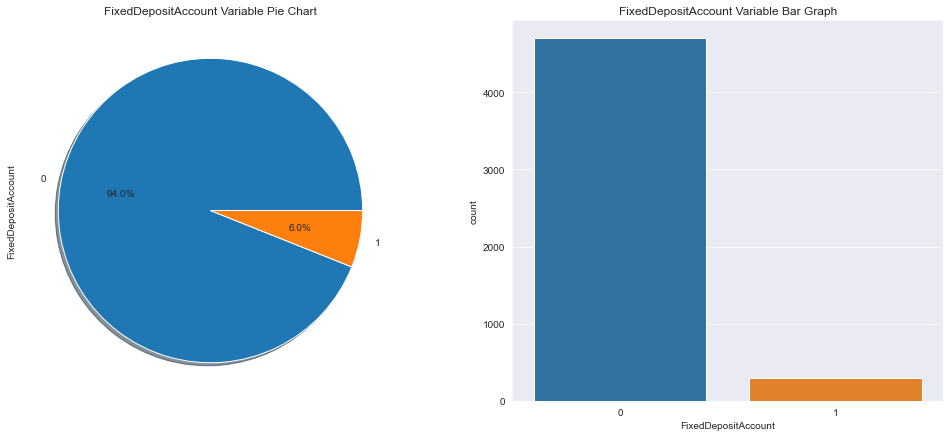

In [44]:
# PART B
# 2. Data Exploration and Analysis:
# C. Check for unexpected values in each categorical variable and impute with best suitable value.
# FixedDepositAccount
f,axes=plt.subplots(1,2,figsize=(17,7))
df_merged['FixedDepositAccount'].value_counts().plot.pie(autopct='%1.1f%%',ax=axes[0],shadow=True)
sns.countplot('FixedDepositAccount',data=df_merged,ax=axes[1])
axes[0].set_title('FixedDepositAccount Variable Pie Chart')
axes[1].set_title('FixedDepositAccount Variable Bar Graph')
plt.show()

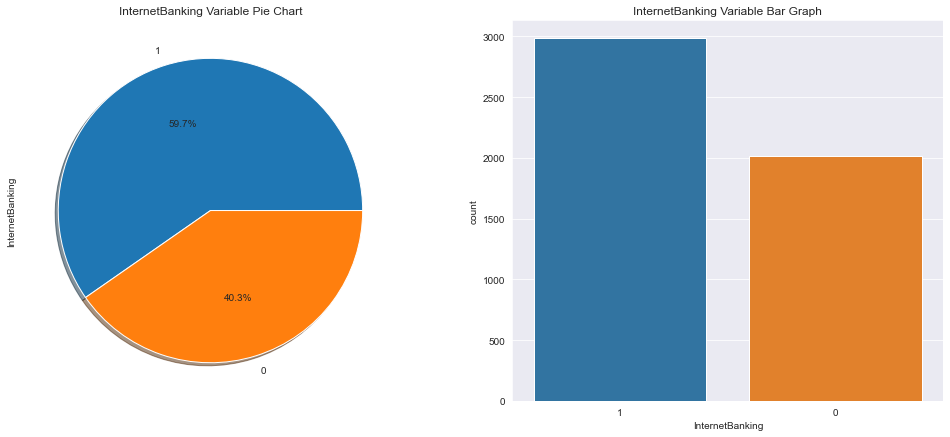

In [45]:
# PART B
# 2. Data Exploration and Analysis:
# C. Check for unexpected values in each categorical variable and impute with best suitable value.
# InternetBanking
f,axes=plt.subplots(1,2,figsize=(17,7))
df_merged['InternetBanking'].value_counts().plot.pie(autopct='%1.1f%%',ax=axes[0],shadow=True)
sns.countplot('InternetBanking',data=df_merged,ax=axes[1],order=[1,0])
axes[0].set_title('InternetBanking Variable Pie Chart')
axes[1].set_title('InternetBanking Variable Bar Graph')
plt.show()

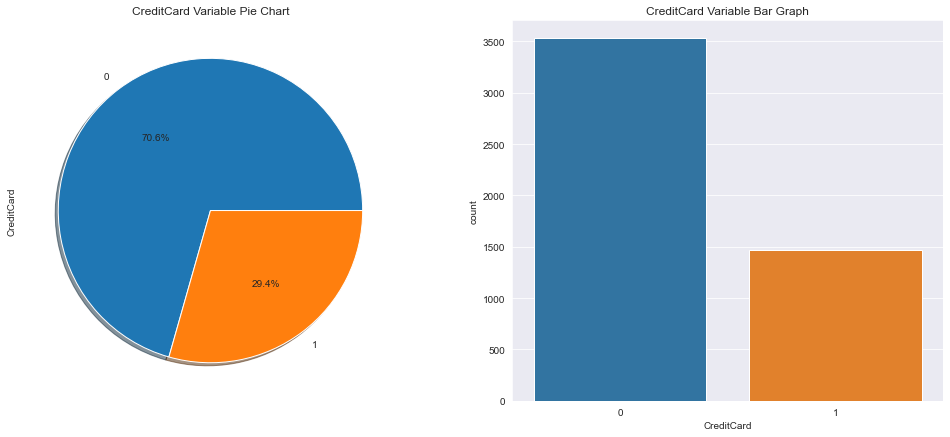

In [46]:
# PART B
# 2. Data Exploration and Analysis:
# C. Check for unexpected values in each categorical variable and impute with best suitable value.
# CreditCard
f,axes=plt.subplots(1,2,figsize=(17,7))
df_merged['CreditCard'].value_counts().plot.pie(autopct='%1.1f%%',ax=axes[0],shadow=True)
sns.countplot('CreditCard',data=df_merged,ax=axes[1],order=[0,1])
axes[0].set_title('CreditCard Variable Pie Chart')
axes[1].set_title('CreditCard Variable Bar Graph')
plt.show()

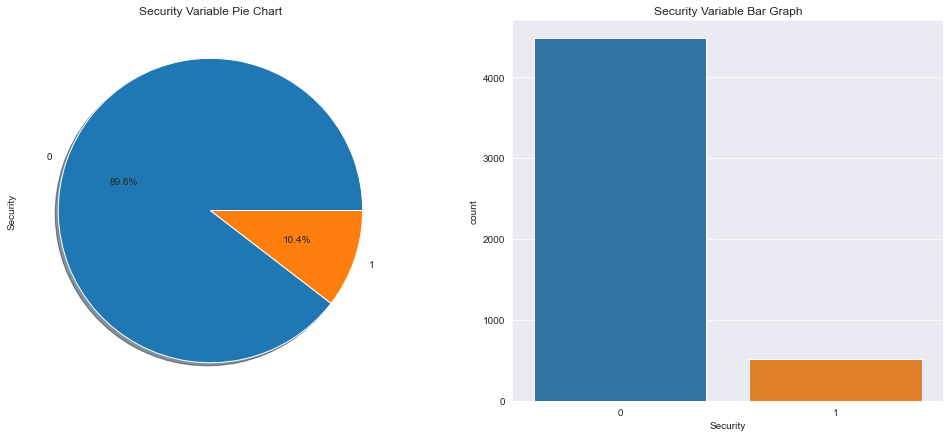

In [33]:
# PART B
# 2. Data Exploration and Analysis:
# C. Check for unexpected values in each categorical variable and impute with best suitable value.
# Security
f,axes=plt.subplots(1,2,figsize=(17,7))
df_merged['Security'].value_counts().plot.pie(autopct='%1.1f%%',ax=axes[0],shadow=True)
sns.countplot('Security',data=df_merged,ax=axes[1],order=[0,1])
axes[0].set_title('Security Variable Pie Chart')
axes[1].set_title('Security Variable Bar Graph')
plt.show()

# PART B
# 2. Data Exploration and Analysis:
# C. Check for unexpected values in each categorical variable and impute with best suitable value.
# Conclusion

> ***There is no unexpected value in categorial variable***

In [8]:
# PART B
# 3. Data Preparation and model building: 
# A. Split data into X and Y
#df_merged['LoanOnCard'] = df_merged['LoanOnCard'].fillna(0)
df_merged.isnull().values.any()
df_merged["LoanOnCard"]=df_merged["LoanOnCard"].astype('float64')
print(df_merged.dtypes)
X1=df_merged.drop(columns='LoanOnCard')
y1=df_merged['LoanOnCard'] #target

ID                       int64
Age                      int64
CustomerSince            int64
HighestSpend             int64
ZipCode                  int64
HiddenScore             object
MonthlyAverageSpend    float64
Level                   object
Mortgage                 int64
Security                object
FixedDepositAccount     object
InternetBanking         object
CreditCard              object
LoanOnCard             float64
dtype: object


In [10]:
# PART B
# 3. Data Preparation and model building: 
# B. Split data into train and test. Keep 25% data reserved for testing. 
X_train2, X_test2, y_train2, y_test2 = train_test_split(X1, y1, test_size=0.25, random_state=10)

In [11]:
# # PART B
# # 3. Data Preparation and model building: 
# # C. Train a Supervised Learning Classification base model - Logistic Regression.
logit2 = LogisticRegression()
logit2.fit(X_train2, y_train2)
logit_pred2 = logit2.predict(X_test2)

print('Accuracy on Training data:',logit2.score(X_train2, y_train2) )
print('Accuracy on Test data:',logit2.score(X_test2, y_test2) )

Accuracy on Training data: 0.9101333333333333
Accuracy on Test data: 0.9024


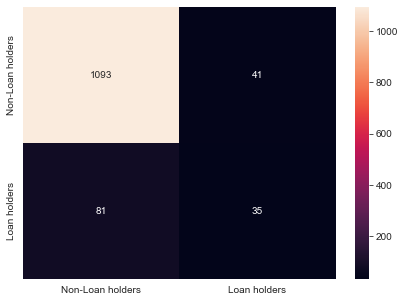

In [11]:
# PART B
# 3. Data Preparation and model building: 
# D. Print evaluation metrics for the model and clearly share insights.
cm1 = confusion_matrix(y_test2, logit_pred2, labels=[0, 1])

df_cm1 = pd.DataFrame(cm1, index = [i for i in ["Non-Loan holders","Loan holders"]],
                  columns = [i for i in ["Non-Loan holders","Loan holders"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm1, annot=True ,fmt='g')
plt.show()

> ***91% accuracy on training set and 90% accuracy on test set.***

> ***Here training set accuracy and testing accuracy are balanced when model is built without sampling also accuracy is good***

In [12]:
# PART B
# 3. Data Preparation and model building: 
# D. Print evaluation metrics for the model and clearly share insights.
print("classification  Matrix:\n",classification_report(y_test2,logit_pred2))

classification  Matrix:
               precision    recall  f1-score   support

         0.0       0.93      0.96      0.95      1134
         1.0       0.46      0.30      0.36       116

    accuracy                           0.90      1250
   macro avg       0.70      0.63      0.66      1250
weighted avg       0.89      0.90      0.89      1250



**Here you can see model is poor in predicting class 1 compared to class 0**

**Accuracy is good but in this case we need to look on recall value**

**Here Recall tells that only 48% class 1 is predicted correctly from actual values**

**We dont have enough sample of class 1 to train the model.**

**We will do the sampling and check how recall values improves in this case.**

In [13]:
# PART B
# 3. Data Preparation and model building: 
# E. Balance the data using the right balancing technique. 
smote_nc=SMOTENC(categorical_features=[1,3,5],random_state=42) #specifying categorical column numbers
x_s,y_s=smote_nc.fit_resample(X1,y1)
print('Before sampling:')
print(y1.value_counts())
print('After sampling:')
print(y_s.value_counts())

Before sampling:
0.0    4520
1.0     480
Name: LoanOnCard, dtype: int64
After sampling:
0.0    4520
1.0    4520
Name: LoanOnCard, dtype: int64


In [14]:
# PART B
# 3. Data Preparation and model building: 
# F. Again train the same previous model on balanced data.
# Split X and y into training and test set in 75:25 ratio
X_train3, X_test3, y_train3, y_test3 = train_test_split(x_s, y_s, test_size=0.25, random_state=10)

In [15]:
# PART B
# 3. Data Preparation and model building: 
# G. Print evaluation metrics and clearly share differences observed.
logit3 = LogisticRegression()
logit3.fit(X_train3, y_train3)
logit_pred3 = logit3.predict(X_test3)

print('Accuracy on Training data:',logit3.score(X_train3, y_train3) )
print('Accuracy on Test data:',logit3.score(X_test3, y_test3) )
print("classification  Matrix:\n",classification_report(y_test3,logit_pred3))

Accuracy on Training data: 0.8638643067846608
Accuracy on Test data: 0.8477876106194691
classification  Matrix:
               precision    recall  f1-score   support

         0.0       0.86      0.84      0.85      1164
         1.0       0.83      0.86      0.85      1096

    accuracy                           0.85      2260
   macro avg       0.85      0.85      0.85      2260
weighted avg       0.85      0.85      0.85      2260



In [16]:
# PART B
# 4. Performance Improvement:
# A: Train a base model each for SVM, KNN
LR_model2=LogisticRegression()
KNN_model2=KNeighborsClassifier(n_neighbors=13)
GN_model2=GaussianNB()
svc_model_linear2 = SVC(kernel='linear',C=1,gamma=.6)
svc_model_rbf2 = SVC(kernel='rbf',degree=2,C=.009)
svc_model_poly2  = SVC(kernel='poly',degree=2,gamma=0.1,C=.01)

In [ ]:
# PART B
# 4. Performance Improvement:
# B. Tune parameters for each of the models wherever required and finalize a model. 
seed = 7
models2 = []
models2.append(('LR', LR_model2))
models2.append(('KNN', KNN_model2))
models2.append(('NB', GN_model2))
models2.append(('SVM-linear', svc_model_linear2))
models2.append(('SVM-poly', svc_model_poly2))
models2.append(('SVM-rbf', svc_model_rbf2))
# evaluate each model in turn
results2 = []
names2 = []
scoring2 = 'accuracy'
for name, model in models2:
	kfold = model_selection.KFold(n_splits=10)
	cv_results = model_selection.cross_val_score(model,  x_s,y_s, cv=kfold, scoring=scoring2)
	results2.append(cv_results)
	names2.append(name)
	msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
	print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results2)
ax.set_xticklabels(names2)
plt.show()

LR: 0.849226 (0.031116)
KNN: 0.508296 (0.327491)
NB: 0.872677 (0.013055)


In [19]:
# PART B
# 4. Performance Improvement:
# C. Print evaluation metrics for final model. 
print("classification  Matrix:\n",classification_report(y_test3,logit_pred3))

classification  Matrix:
               precision    recall  f1-score   support

         0.0       0.86      0.84      0.85      1164
         1.0       0.83      0.86      0.85      1096

    accuracy                           0.85      2260
   macro avg       0.85      0.85      0.85      2260
weighted avg       0.85      0.85      0.85      2260



# PART B
# 4. Performance Improvement:
# D. Share improvement achieved from base model to final model
> ***Very slight improvement in accuracy***